## Problem Understanding

The goal of this project is to classify wine into different categories 
based on chemical properties.

This is a supervised classification problem.

Target variable:
Wine class (0,1,2)

Features:
Alcohol, Malic acid, Magnesium, Color intensity, etc.

Objective:
Train a classification model to correctly predict the wine category.

# Import Libraries

In [17]:
# TODO: Import pandas, numpy, matplotlib.pyplot, seaborn
# TODO: Import train_test_split, StandardScaler
# TODO: Import LinearRegression, metrics (mean_absolute_error, mean_squared_error, r2_score)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add your scikit-learn imports below:
from sklearn.datasets import _california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



# Load Dataset

In [24]:
from sklearn.datasets import load_wine

# Load the dataset
wine = load_wine(as_frame=True) # Return the dataset as a Pandas DataFrame instead of NumPy arrays
print(wine)
df = wine.frame

df.head()

# target name
#wine.target_names = How many classes does this data set have - array(['class_0', 'class_1', 'class_2'])

{'data':      alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0      14.23        1.71  2.43               15.6      127.0           2.80   
1      13.20        1.78  2.14               11.2      100.0           2.65   
2      13.16        2.36  2.67               18.6      101.0           2.80   
3      14.37        1.95  2.50               16.8      113.0           3.85   
4      13.24        2.59  2.87               21.0      118.0           2.80   
..       ...         ...   ...                ...        ...            ...   
173    13.71        5.65  2.45               20.5       95.0           1.68   
174    13.40        3.91  2.48               23.0      102.0           1.80   
175    13.27        4.28  2.26               20.0      120.0           1.59   
176    13.17        2.59  2.37               20.0      120.0           1.65   
177    14.13        4.10  2.74               24.5       96.0           2.05   

     flavanoids  nonflavanoid_phenols  pro

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


# Data Understanding

In [ ]:
print("shape")
print(df.shape) # (rows, columns)

print("info ")
print(df.info())

print("describe ")
print(df.describe())



shape
(178, 14)
info 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null

# Data Cleaning

In [ ]:
# Check missing values
print("Does this Dataset contain any null values")
print(df.isnull().sum()) # isnull() checks each cell in the dataset and returns: True - missing value(NAN), False: value exists
# isnull.sum() - sum() counts the number of True values in each column.

# Check duplicates
print("Does this Dataset contain any duplicate values")
print(df.duplicated().sum())

# This Data set does not conatin any null values and duplicates


Does this Dataset contain any null values
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64
Does this Dataset contain any duplicate values
0


# EDA + VISUALISATIONS

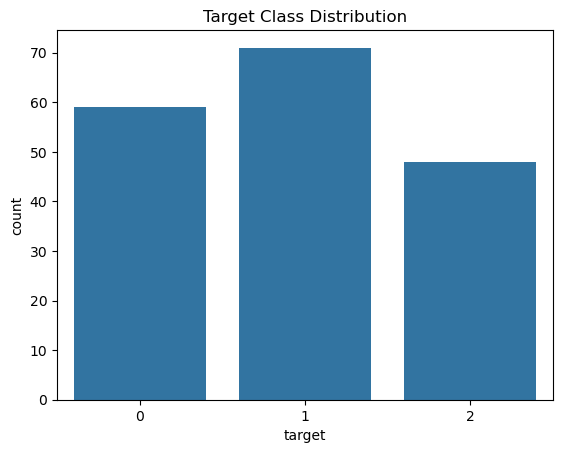

In [ ]:
target_col = "target" 

sns.countplot(x=target_col, data=df)
plt.title("Target Class Distribution")
plt.show()

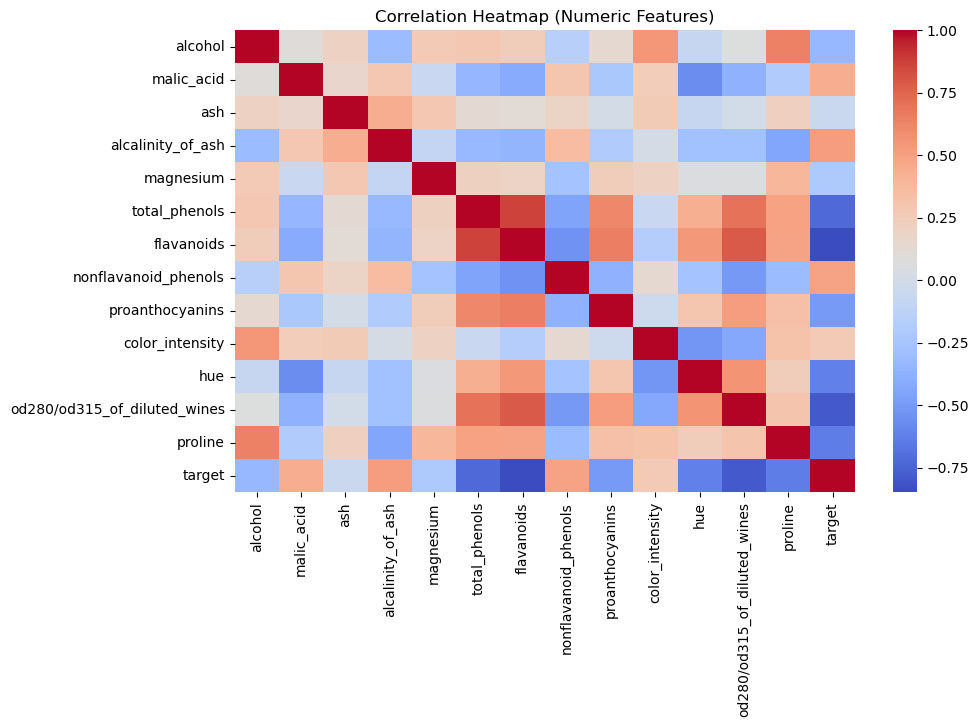

In [7]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

# DATA CLEANING & PRE PROCESSING

In [ ]:
# SPLIT X AND Y
X = df.drop(target_col, axis=1)
y = df[target_col]

In [10]:
#Train Test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# MODEL TRAINING

In [14]:
# LOGISTIC REGRESSION
log_model = LogisticRegression(max_iter=3000)
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

In [16]:
# DECISION TREE - NO SCALING REQUIRED
dt_model = DecisionTreeClassifier(random_state=42, max_depth=8)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# Evaluation (Classification)

In [19]:
# Logistic Regression Metrics
print("==== Logistic Regression ====")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

#Decision Tree Metrcis
print("==== Decision Tree ====")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

==== Logistic Regression ====
Accuracy: 0.9722222222222222
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36

Confusion Matrix:
 [[12  0  0]
 [ 0 14  0]
 [ 0  1  9]]
==== Decision Tree ====
Accuracy: 0.9444444444444444
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.88      1.00      0.93        14
           2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36

Confusion Matrix:
 [[11  1  0]
 [ 0 14  0]
 [ 0  1  9]]
